<a href="https://colab.research.google.com/github/mfernandezzz/Pruebas_Tecnicas/blob/main/pruebaTecnicaSpotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**¿Cual es la cancion mas escuchada de todo Spotify?**

La cantidad de reproducciones esta contenida en la columna streams.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/spotify.csv')
df.head()

,Unnamed: 0,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,...,125,B,Major,80,89,83,31,0,8,4
1,1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,...,92,C#,Major,71,61,74,7,0,10,4
2,2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,...,138,F,Major,51,32,53,17,0,31,6
3,3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,...,170,A,Major,55,58,72,11,0,11,15
4,4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,...,144,A,Minor,65,23,80,14,63,11,6


In [ ]:
df.shape[0]

953

Se obtiene la cantidad maxima de reproducciones ('streams')

In [ ]:
max_streams = df['streams'].max()
max_streams

3703895074

Datos de la cancion con mas cantidad de reproducciones

In [ ]:
df.loc[df['streams'] == max_streams][['track_name', 'artist(s)_name', 'released_year', 'released_month', 'released_day', 'in_spotify_playlists']]

,track_name,artist(s)_name,released_year,released_month,released_day,in_spotify_playlists
55,Blinding Lights,The Weeknd,2019,11,29,43899


Otra solucion:

In [ ]:
streams = df.sort_values('streams', ascending=False)
streams[['track_name', 'artist(s)_name', 'in_spotify_playlists', 'streams']].iloc[0]

,55
track_name,Blinding Lights
artist(s)_name,The Weeknd
in_spotify_playlists,43899
streams,3703895074


**¿Cual es la cancion que se encuentra en mas cantidad de playlists?**

Se obtiene el valor maximo contenido en la columna 'in_spotify_playlists'

In [ ]:
max_playlists = df['in_spotify_playlists'].max()
max_playlists

52898

Datos de la cancion que se encuentra en mas cantidad de playlists

In [ ]:
song_playlist = df.loc[df['in_spotify_playlists'] == 52898]
song_playlist[['track_name', 'artist(s)_name', 'released_year', 'in_spotify_playlists', 'streams']]

,track_name,artist(s)_name,released_year,in_spotify_playlists,streams
757,Get Lucky - Radio Edit,"Pharrell Williams, Nile Rodgers, Daft Punk",2013,52898,933815613


**¿Que cancion de Spotify fue la mas escuchada en 2023?**

In [ ]:
df.columns

Index(['Unnamed: 0', 'track_name', 'artist(s)_name', 'artist_count',
       'released_year', 'released_month', 'released_day',
       'in_spotify_playlists', 'in_spotify_charts', 'streams',
       'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists',
       'in_deezer_charts', 'in_shazam_charts', 'bpm', 'key', 'mode',
       'danceability_%', 'valence_%', 'energy_%', 'acousticness_%',
       'instrumentalness_%', 'liveness_%', 'speechiness_%'],
      dtype='object')

In [ ]:
df['released_year'].value_counts().head(10)

,count
released_year,
2022,402
2023,175
2021,119
2020,37
2019,36
2017,23
2016,18
2013,13
2014,13


Nuevo DataFrame solo con las canciones de 2023

In [ ]:
mask = df['released_year'] == 2023
df_2023 = df[mask]
df_2023.shape[0]

175

Cantidad maxima de reproducciones que tuvo la cancion mas escuchada de 2023

In [ ]:
df_2023['streams'].max()

1316855716

Datos de la cancion mas escuchada de 2023

In [ ]:
most_popular_song_2023 = df.loc[df['streams'] == df_2023['streams'].max()]
most_popular_song_2023[['track_name', 'artist(s)_name', 'released_year', 'in_spotify_playlists', 'streams']]

,track_name,artist(s)_name,released_year,in_spotify_playlists,streams
12,Flowers,Miley Cyrus,2023,12211,1316855716


Otra solucion:

In [ ]:
spotify_2023 = df.loc[df['released_year'] == 2023]
spotify_2023.sort_values('streams', ascending=False)[['track_name', 'artist(s)_name', 'streams']].head(1)

,track_name,artist(s)_name,streams
12,Flowers,Miley Cyrus,1316855716


**Crear un grafico de barras con los cinco artistas mas escuchados**

Agrupar a los 5 artistas mas populares junto con las reproducciones totales de todas sus canciones

In [ ]:
df.columns

Index(['Unnamed: 0', 'track_name', 'artist(s)_name', 'artist_count',
       'released_year', 'released_month', 'released_day',
       'in_spotify_playlists', 'in_spotify_charts', 'streams',
       'in_apple_playlists', 'in_apple_charts', 'in_deezer_playlists',
       'in_deezer_charts', 'in_shazam_charts', 'bpm', 'key', 'mode',
       'danceability_%', 'valence_%', 'energy_%', 'acousticness_%',
       'instrumentalness_%', 'liveness_%', 'speechiness_%'],
      dtype='object')

In [ ]:
df['artist(s)_name'].value_counts().head()

,count
artist(s)_name,
Taylor Swift,34
The Weeknd,22
SZA,19
Bad Bunny,19
Harry Styles,17


In [ ]:
# se crea una Serie donde el nombre de los artistas es el indice y las reproducciones los valores asociados

# se agrupa por nombre del artista y cantidad de reproducciones totales
artists_total_streams = df.groupby('artist(s)_name')['streams'].sum()

# se ordenan los valores de la Serie en orden descendente
top_5 = artists_total_streams.sort_values(ascending=False).head()
top_5

,streams
artist(s)_name,
The Weeknd,14185552870
Taylor Swift,14053658300
Ed Sheeran,13908947204
Harry Styles,11608645649
Bad Bunny,9997799607


In [ ]:
# se crea un DataFrame con los nombres de los artistas y las reproducciones como columnas

# se agrupa por artista y cantidad de reproducciones totales (se conserva el indice original)
artists_total_streams = df.groupby(by='artist(s)_name', as_index=False)['streams'].sum()

# se ordena el DataFrame en orden descendente de la columna streams
top_5 = artists_total_streams.sort_values(by='streams', ascending=False).head()
top_5

,artist(s)_name,streams
572,The Weeknd,14185552870
558,Taylor Swift,14053658300
159,Ed Sheeran,13908947204
223,Harry Styles,11608645649
43,Bad Bunny,9997799607


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

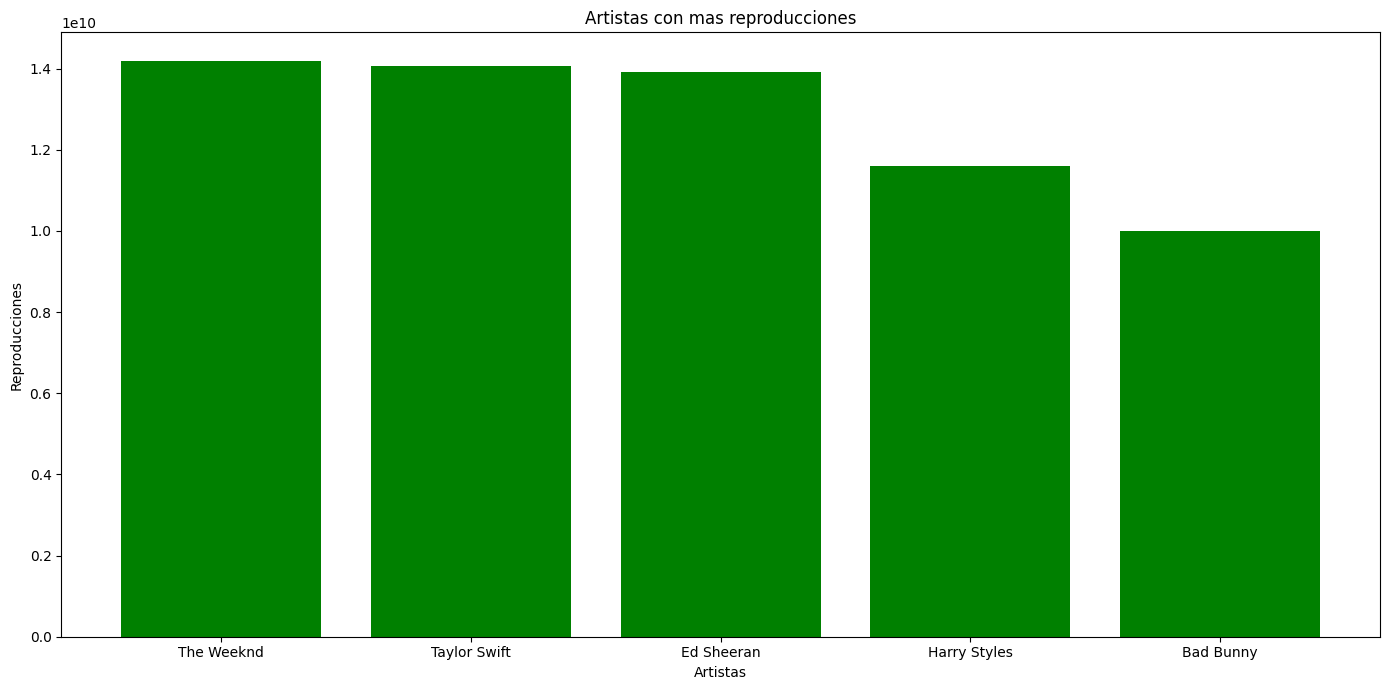

In [ ]:
x = top_5['artist(s)_name']
y = top_5['streams']

plt.figure(figsize=(14, 7))
plt.bar(x, y, color='g')

plt.title('Artistas con mas reproducciones')
plt.xlabel('Artistas')
plt.ylabel('Reproducciones')

plt.tight_layout()
plt.show()


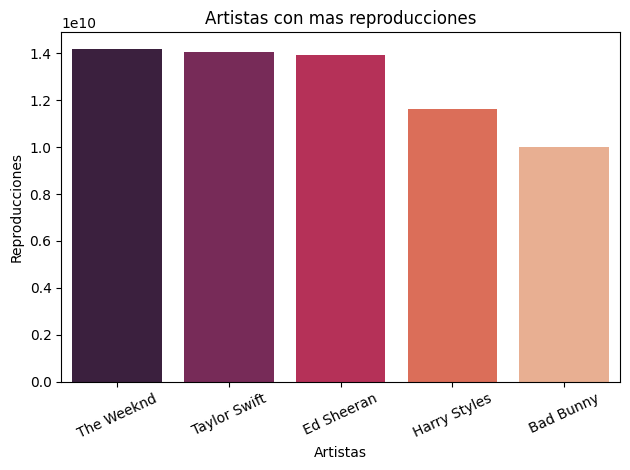

In [ ]:
sns.barplot(x=x, y=y, palette='rocket', hue=x, dodge=False)
plt.xticks(rotation=25)

plt.title('Artistas con mas reproducciones')
plt.xlabel('Artistas')
plt.ylabel('Reproducciones')

plt.tight_layout()
plt.show()